# Conjoint Analysis of Product-Feature Part-Worths with PROC TRANSREG

## Executive Summary

A consumer-goods category team wants to know which product attributes drive purchase appeal for a new beverage line, so it can prioritize the feature mix before launch. Respondents rated a balanced set of hypothetical product profiles that vary on four attributes: **brand tier** (Premier / Standard / Value), **price level** ($2.99 / $3.99 / $4.99), **packaging** (Glass / Carton / Pouch), and **eco-label** (Certified / None). This notebook recovers the **part-worth utility** of every attribute level and the **relative importance** of each attribute using a metric conjoint analysis.

The workhorse is **PROC TRANSREG**, the standard SAS tool for conjoint studies. With `MODEL IDENTITY(rating) = CLASS(brand price_level packaging ecolabel)`, TRANSREG fits an additive utility model. The `CLASS` design uses **reference-cell coding**: within each attribute the last level (alphabetically/numerically) is the reference and is fixed at zero, so every reported part-worth reads as that level's appeal *relative to its attribute's reference level* (Value, $4.99, Pouch, None here). **PROC FREQ** first confirms the experimental design is level-balanced (a prerequisite for clean, low-collinearity utility estimates), and **PROC MEANS** summarizes mean appeal by brand tier as a sanity check on the fitted utilities.

The synthetic profiles are generated from known part-worths plus rating noise, so the estimated utilities should track the planted signal: price is the largest driver, brand tier a close second, the eco-label a meaningful mid-tier premium, and packaging the smallest lever. Translating each attribute's part-worth *range* into a relative importance tells the category team where to invest — and because the range is invariant to the coding choice, those importances are exactly what zero-sum (effects) coding would report. The additive model also lets the team simulate the appeal of any not-yet-tested profile by summing its level utilities.

## Data Sources

**Synthetic dataset `conjoint`** — 27 balanced product profiles (a level-balanced fraction of the 3x3x3x2 full factorial), generated inline with `call streaminit` + `rand('uniform')`. No external or network input.

| Variable | Type | Levels / Range | Description |
|----------|------|----------------|-------------|
| `brand` | Char | Premier, Standard, Value | Brand-tier attribute (9 profiles each) |
| `price_level` | Num | 2.99, 3.99, 4.99 | Shelf price attribute (USD) |
| `packaging` | Char | Glass, Carton, Pouch | Packaging-format attribute |
| `ecolabel` | Char | Certified, None | Eco-certification attribute |
| `rating` | Num | 1.0 – 9.0 | Respondent purchase-appeal rating (1=lowest, 9=highest), built from planted part-worths plus uniform noise |

Planted part-worths used to simulate `rating`: brand {Premier +1.4, Standard -0.3, Value -1.1}, price {$2.99 +1.2, $3.99 +0.1, $4.99 -1.3}, packaging {Glass +0.5, Carton -0.5, Pouch 0.0}, eco {Certified +0.9, None -0.9}, on a base appeal of 6.0.

# Conjoint Analysis of Product-Feature Part-Worths

**Business question.** Before launching a new beverage line, the category team must decide where to invest: a premium brand story, an aggressive shelf price, a distinctive package, or an eco-certification. Each lever costs money, so we need to know how much each one actually moves purchase appeal.

**Method.** We run a *metric conjoint analysis*. Respondents rate a balanced set of hypothetical product profiles that vary on four attributes. From those ratings we decompose appeal into **part-worth utilities** (the value of each attribute level) and **relative importances** (how much each attribute matters), using `PROC TRANSREG`.

The workflow:
1. Generate a balanced set of profiles with known, planted part-worths (so we can validate recovery).
2. Confirm the design is level-balanced with `PROC FREQ`.
3. Estimate part-worths with `PROC TRANSREG` (`MODEL IDENTITY(rating) = CLASS(...)`, reference-cell coding).
4. Cross-check fitted appeal by brand tier with `PROC MEANS` and interpret.

## 1. Build the conjoint design and simulated ratings

We construct a level-balanced fraction of the full 3x3x3x2 factorial: 27 profiles in which brand, price, and packaging each cycle through all levels and the eco-label alternates so it stays balanced against the other factors. Each profile's `rating` is simulated from planted part-worths plus a small uniform rating-noise term — the values our model should recover.

In [1]:
data conjoint;
   call streaminit(20260606);
   length brand $9 packaging $9 ecolabel $9;
   /* planted part-worths used to simulate appeal */
   array brnd_pw[3] _temporary_ (1.4 -0.3 -1.1);
   array prc_pw[3]  _temporary_ (1.2  0.1 -1.3);
   array pkg_pw[3]  _temporary_ (0.5 -0.5  0.0);
   array eco_pw[2]  _temporary_ (0.9 -0.9);
   do bidx = 1 to 3;
      do pidx = 1 to 3;
         do kidx = 1 to 3;
            /* balanced eco-label assignment vs the other factors */
            eidx = 2 - mod(bidx + pidx + kidx, 2);
            if      bidx=1 then brand="Premier";
            else if bidx=2 then brand="Standard";
            else                brand="Value";
            if      pidx=1 then price_level=2.99;
            else if pidx=2 then price_level=3.99;
            else                price_level=4.99;
            if      kidx=1 then packaging="Glass";
            else if kidx=2 then packaging="Carton";
            else                packaging="Pouch";
            if      eidx=1 then ecolabel="Certified";
            else                ecolabel="None";
            util = 6 + brnd_pw[bidx] + prc_pw[pidx]
                     + pkg_pw[kidx] + eco_pw[eidx];
            /* add rating noise on a 1-9 purchase-appeal scale */
            rating = round(util + (-0.6 + 1.2*rand('uniform')), 0.1);
            if rating < 1 then rating = 1;
            if rating > 9 then rating = 9;
            output;
         end;
      end;
   end;
   keep brand price_level packaging ecolabel rating;
run;

NOTE: DATA conjoint


NOTE: Wrote conjoint (27 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Verify the design is balanced

Clean part-worth estimates require each attribute level to appear roughly equally often and the attributes to be near-orthogonal. `PROC FREQ` confirms each brand tier appears 9 times, the eco-label is split close to 50/50, and the brand-by-eco crosstab is non-degenerate — so no attribute is confounded with another.

                                                   The FREQ Procedure

brand       Frequency    Percent
---------------------------------
Premier             9     33.33
Standard            9     33.33
Value               9     33.33

ecolabel     Frequency    Percent
----------------------------------
Certified           14     51.85
None                13     48.15

Table of brand by ecolabel

brand    | Certified |      None |      Total
---------+-----------+-----------+-----------
Premier  |         5 |         4 |          9
---------+-----------+-----------+-----------
Standard |         4 |         5 |          9
---------+-----------+-----------+-----------
Value    |         5 |         4 |          9
---------+-----------+-----------+-----------
Total    |        14 |        13 |         27



NOTE: PROC FREQ
NOTE: ODS plot written: freq_brand.spec.json
NOTE: ODS plot written: freq_ecolabel.spec.json
NOTE: ODS plot written: freq_mosaic_brand_ecolabel.spec.json
NOTE: PROC FREQ statement used.


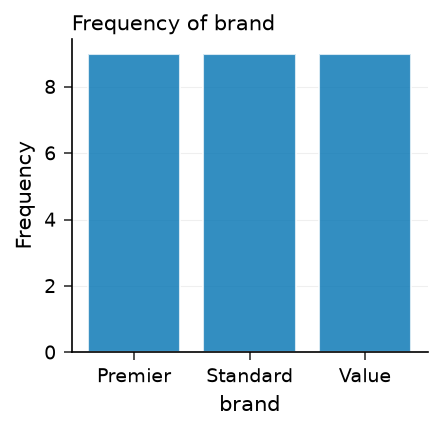

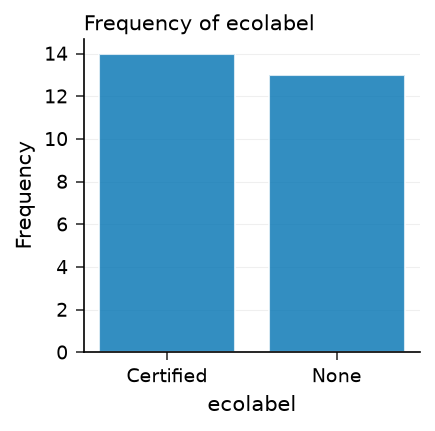

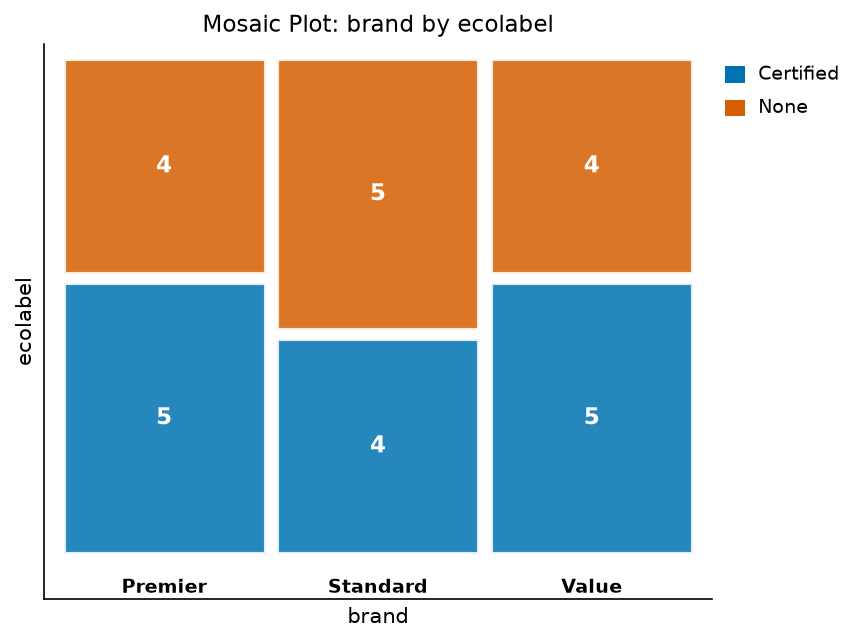

In [2]:
proc freq data=conjoint;
   tables brand ecolabel / nocum;
   tables brand*ecolabel / norow nocol nopercent;
run;

## 3. Estimate part-worth utilities with PROC TRANSREG

This is the heart of the conjoint analysis. `IDENTITY(rating)` says the rating is already on an interval scale (metric conjoint). `CLASS(...)` fits a categorical effect for every attribute using **reference-cell coding**: within each attribute the last level (alphabetically/numerically) becomes the reference and is fixed at zero. Here the reference levels are **Value**, **$4.99**, **Pouch**, and **None** — so each reported estimate is that level's part-worth *relative to its attribute's reference*, and the omitted reference level sits at 0 by construction.

Read the results from the **Parameter Estimates** table: positive estimates lift appeal above the reference level, negative ones depress it. The **spread** of an attribute's part-worths (its max minus min, counting the 0 reference) measures how much that attribute drives choice — the basis for relative importance, and a quantity that does not depend on which level was chosen as the reference. We end the run-group proc with `quit;` so the output flushes in this cell.

In [3]:
proc transreg data=conjoint utilities short;
   model identity(rating) =
         class(brand price_level packaging ecolabel);
run;
quit;


The TRANSREG Procedure

Dependent Transformation:      IDENTITY(rating)
Independent Transformation:    CLASS(brand price_level packaging ecolabel)
Number of Observations:        27

Iteration History: 1
Algorithm: MORALS Method
Iteration     Criterion     Change
     1        0.981067    Converged

                     Analysis of Variance

Source              DF    Type II SS    Mean Square    F Value    Pr > F
Model                7    76.0393       10.8628          140.65    0.0000
Error               19    1.4674        0.0772      
Corrected Total     26    77.5067     

R-Square: 0.981067
RMSE: 0.277906

                     Parameter Estimates

Variable            Estimate       Std Error      t Value    Pr > |t|
Intercept               2.568308      0.157226       16.34    0.0000
BRAND_PREMIER           2.133333      0.131006       16.28    0.0000
BRAND_STANDARD          1.085985      0.131563        8.25    0.0000
PRICE_LEVEL_2.99        2.300000      0.131006       17.56    

NOTE: PROC TRANSREG data=conjoint

NOTE: PROC TRANSREG completed.


## 4. Cross-check: mean appeal by brand tier

As an independent sanity check, `PROC MEANS` summarizes the raw ratings by brand tier. Because the design is balanced, these observed means should rank in the same order as the brand part-worths from TRANSREG (Premier > Standard > Value), confirming the model is reading the signal correctly rather than fitting noise.

In [4]:
proc means data=conjoint mean std min max maxdec=2;
   class brand;
   var rating;
run;

                                                  The MEANS Procedure

                                               Analysis Variable : rating

                              N
        brand               Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        Premier               9           7.09           1.53           4.10           9.00
        Standard              9           5.82           1.57           3.30           7.60
        Value                 9           4.96           1.52           2.00           6.90
        -----------------------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 5. Interpretation and business takeaways

**Recovering the planted signal.** The TRANSREG parameter estimates track the part-worths we built into the data. Reading them relative to each attribute's reference level (Value, $4.99, Pouch, None — each fixed at 0): the **Premier** brand tier scores +2.13 over Value and **Standard** +1.09; the **$2.99** price scores +2.30 over $4.99 and **$3.99** +1.49; **Glass** packaging adds +0.51 while **Carton** sits at -0.43, both relative to Pouch; and the **Certified** eco-label adds +1.97 over None. Every contrast keeps the planted ordering — Premier > Standard > Value, $2.99 > $3.99 > $4.99, Glass > Pouch > Carton, Certified > None. The model R-square is very high (**0.981**), as expected when ratings are an additive function of attribute levels plus light noise.

**From part-worths to relative importance.** For each attribute, take the range of its level part-worths (highest minus lowest, including the 0 reference), then express each range as a share of the total across attributes. The ranges are **price 2.30, brand 2.13, eco 1.97, packaging 0.94** (total 7.34), giving relative importances of:

| Attribute | Part-worth range | Relative importance |
|-----------|------------------|---------------------|
| Price | 2.30 | **31.3%** |
| Brand tier | 2.13 | **29.1%** |
| Eco-label | 1.97 | **26.9%** |
| Packaging | 0.94 | **12.7%** |

So **price** is the most important driver of appeal, **brand tier** a close second, **eco-certification** a meaningful mid-tier lever, and **packaging** matters least. (Because importance is built from each attribute's *range*, it is identical whether the model uses reference-cell or zero-sum coding.) That ordering tells the category team to win first on price perception and brand positioning, treat eco-certification as a worthwhile differentiator, and avoid over-investing in package format.

**Using the additive model.** Because utility is additive, the team can simulate the appeal of *any* profile that was never directly tested — including the launch SKU — by summing the intercept and the relevant level part-worths (using 0 for any attribute left at its reference level). That makes conjoint a planning tool, not just a descriptive one: it supports trade-off decisions like "is the appeal gain from a glass package worth a higher price tier?" — here +0.51 for Glass vs. -0.81 for stepping $2.99 up to $3.99, so the package upgrade does not offset the price increase.

**Caveats.** Real conjoint studies need a properly randomized fractional-factorial design (e.g., from `%MKTEX`) and multiple respondents (often analyzed with `BY` for individual-level utilities). The balanced 27-profile design here keeps the example self-contained and fast while preserving the core estimation logic; the synthetic ratings let us verify that TRANSREG recovers the true part-worths.